<a href="https://colab.research.google.com/github/madaam99/EnergyGermany/blob/main/Modelling/Modelling_SMARD_Consumption_Germany_Monthly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install utilsforecast statsforecast mlforecast neuralforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.2/263.2 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.7/280.7 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from google.colab import files

In [3]:
upload = files.upload()

Saving processedVerbrauchMonthly to processedVerbrauchMonthly


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, SeasonalNaive

from mlforecast import MLForecast
from mlforecast.target_transforms import LocalStandardScaler
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS, TFT

import warnings
warnings.filterwarnings('ignore')

In [5]:
verbrauch = pd.read_csv("processedVerbrauchMonthly")

verbrauch.tail()

,Datum von,Datum bis,Gesamtlast [MWh],Netzlast [MWh],Netzlast inkl. Pumpspeicher [MWh],Pumpspeicher [MWh],Residuallast [MWh]
54,2025-07-01,2025-08-01,57977024.16,36858757.61,37903688.11,1044930.50,20073336.05
55,2025-08-01,2025-09-01,55552980.90,35640058.55,36743438.30,1103379.75,18809542.60
56,2025-09-01,2025-10-01,56044932.24,36808238.41,37804272.91,996034.50,18240659.33
57,2025-10-01,2025-11-01,61925792.95,40678379.09,41700126.48,1021747.39,20225666.47
58,2025-11-01,2025-12-01,69605993.86,41824387.41,42732501.40,908113.99,26873492.46


In [6]:
verbrauch = verbrauch.loc[~(verbrauch[verbrauch.columns[2:]] == 0).any(axis=1)]

verbrauch['Datum von'] = pd.to_datetime(verbrauch['Datum von'])
verbrauch['Datum bis'] = pd.to_datetime(verbrauch['Datum bis'])

##Modelling with Consumption as Focus

In [7]:
verbrauch_melted = verbrauch.drop(columns="Datum bis").melt(id_vars=['Datum von'], var_name='unique_id', value_name='y')

verbrauch_melted.rename(columns={'Datum von': 'ds'}, inplace=True)

verbrauch_melted.head()

,ds,unique_id,y
0,2021-01-01,Gesamtlast [MWh],80212151.13
1,2021-02-01,Gesamtlast [MWh],71188575.25
2,2021-03-01,Gesamtlast [MWh],75235874.25
3,2021-04-01,Gesamtlast [MWh],68086182.00
4,2021-05-01,Gesamtlast [MWh],65356819.25


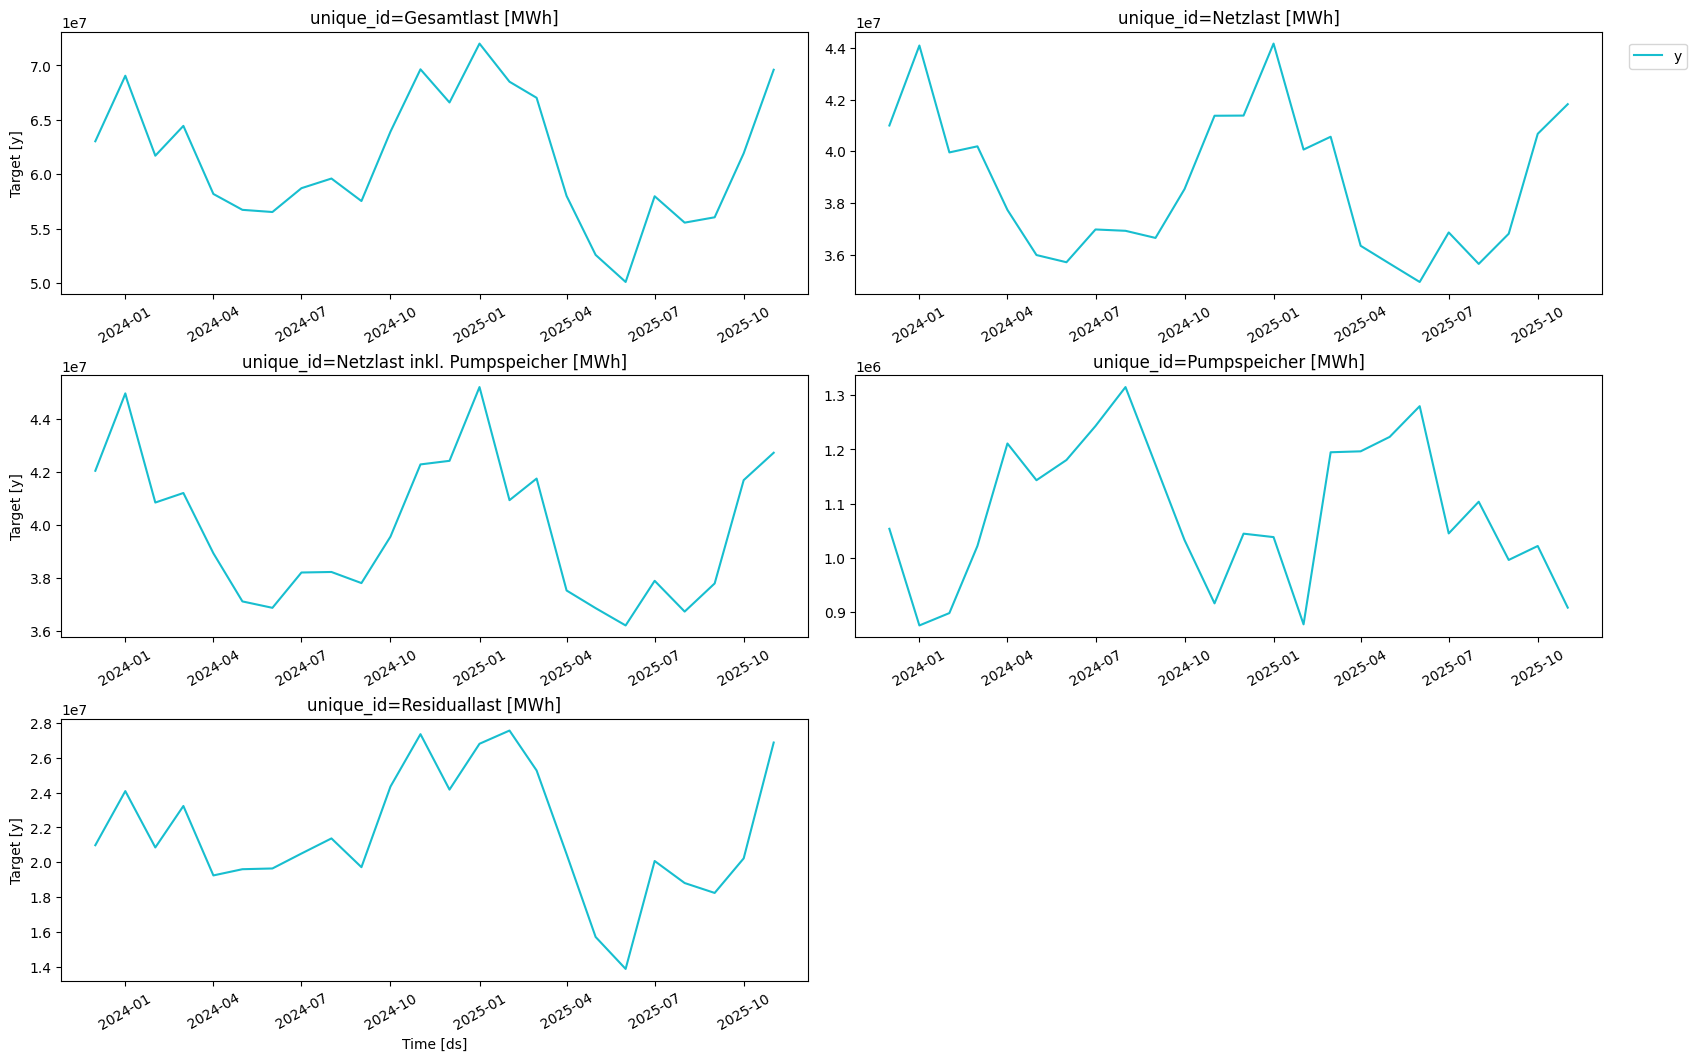

In [8]:
plot_series(df=verbrauch_melted, max_insample_length=24)

Statsforecast

In [9]:
testVerbrauchStat = verbrauch_melted.groupby('unique_id').tail(3)
trainVerbrauchStat = verbrauch_melted.drop(testVerbrauchStat.index)

In [10]:
models = [
    AutoARIMA(alias="ARIMA"),
    AutoARIMA(season_length=12, alias="SARIMA"),
    SeasonalNaive(season_length=12)
]

sf = StatsForecast(models=models, freq='MS')
sf.fit(trainVerbrauchStat)
predStatVer = sf.predict(3)

predStatVer.head()

,unique_id,ds,ARIMA,SARIMA,SeasonalNaive
0,Gesamtlast [MWh],2025-09-01,5.636930e+07,5.543007e+07,57537546.25
1,Gesamtlast [MWh],2025-10-01,5.609440e+07,6.066466e+07,63916158.75
2,Gesamtlast [MWh],2025-11-01,5.618698e+07,6.706728e+07,69646332.75
3,Netzlast [MWh],2025-09-01,3.739869e+07,3.593658e+07,36646160.50
4,Netzlast [MWh],2025-10-01,3.693534e+07,3.797908e+07,38537384.00


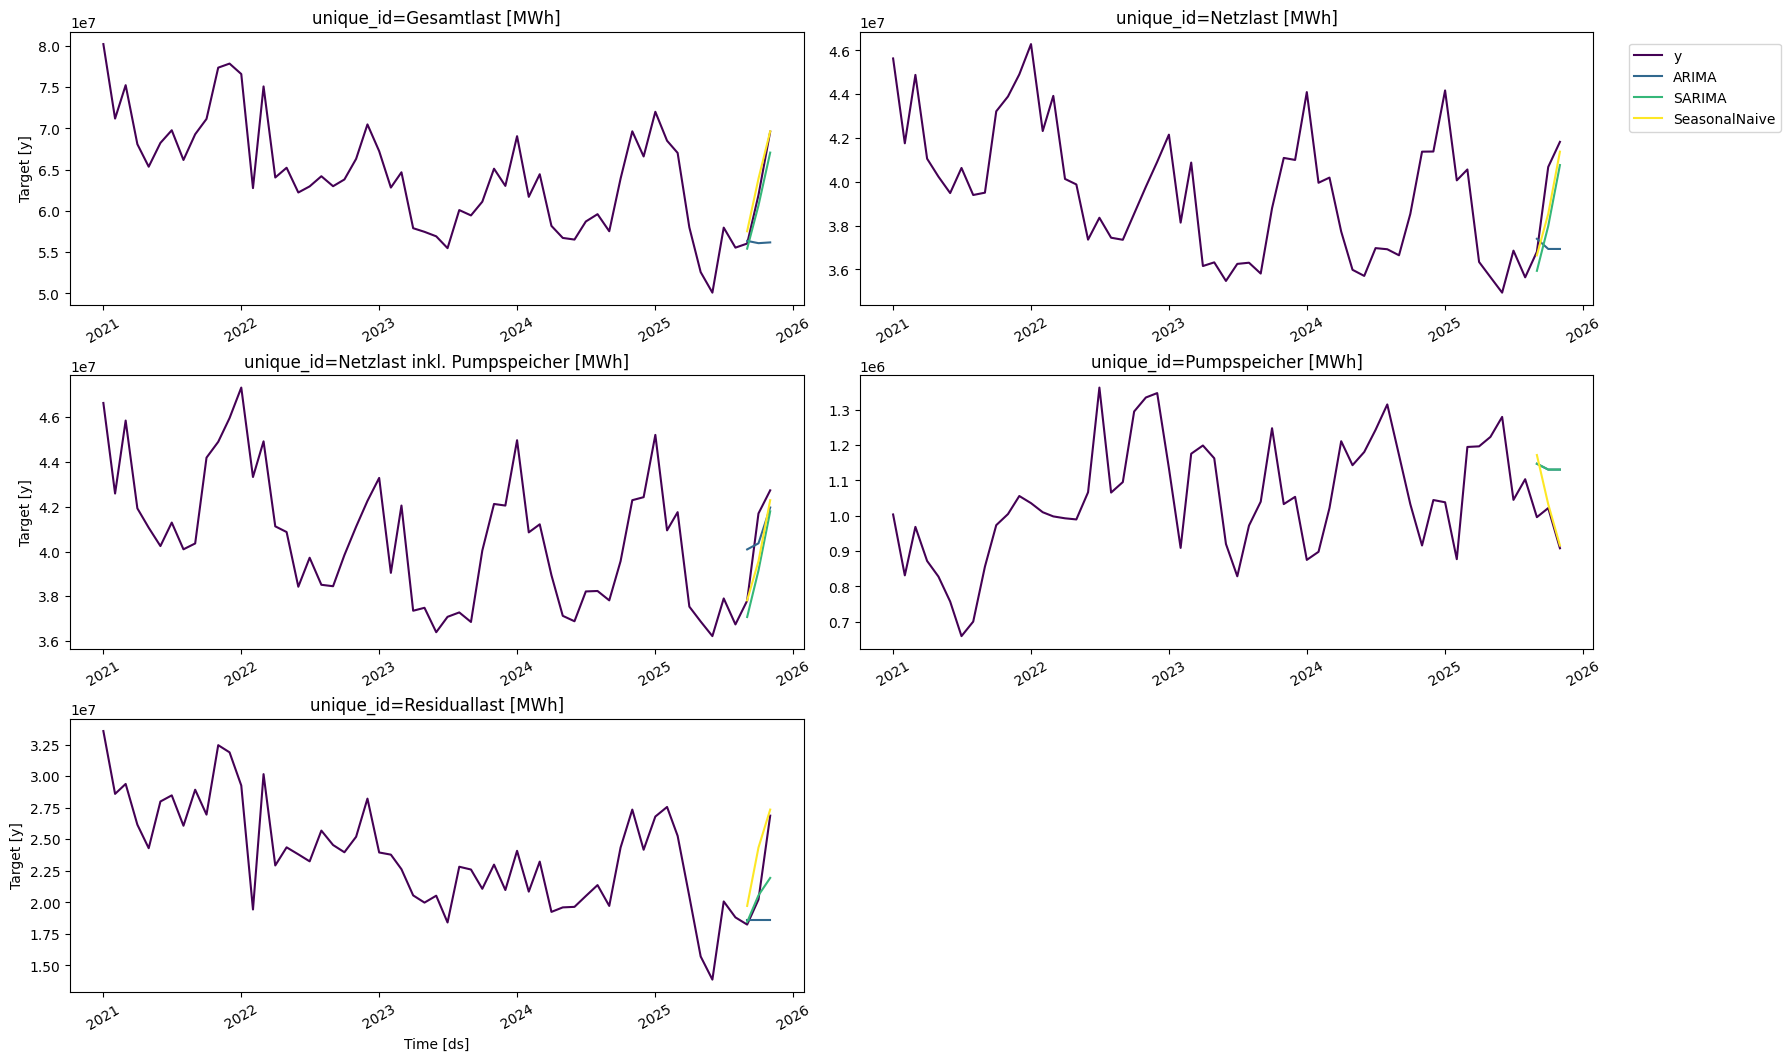

In [11]:
plot_series(df=verbrauch_melted, forecasts_df=predStatVer, palette="viridis")

In [12]:
eval_df = pd.merge(testVerbrauchStat, predStatVer, "left", ["ds", "unique_id"])
evaluation = evaluate(eval_df, metrics=[mae])
evaluation.head()

,unique_id,metric,ARIMA,SARIMA,SeasonalNaive
0,Gesamtlast [MWh],mae,6.524928e+06,1.471568e+06,1.174440e+06
1,Netzlast [MWh],mae,3.074179e+06,1.543390e+06,9.169801e+05
2,Netzlast inkl. Pumpspeicher [MWh],mae,1.463376e+06,1.405579e+06,8.612592e+05
3,Pumpspeicher [MWh],mae,1.608387e+05,1.608387e+05,6.484537e+04
4,Residuallast [MWh],mae,3.417848e+06,1.823968e+06,2.026574e+06


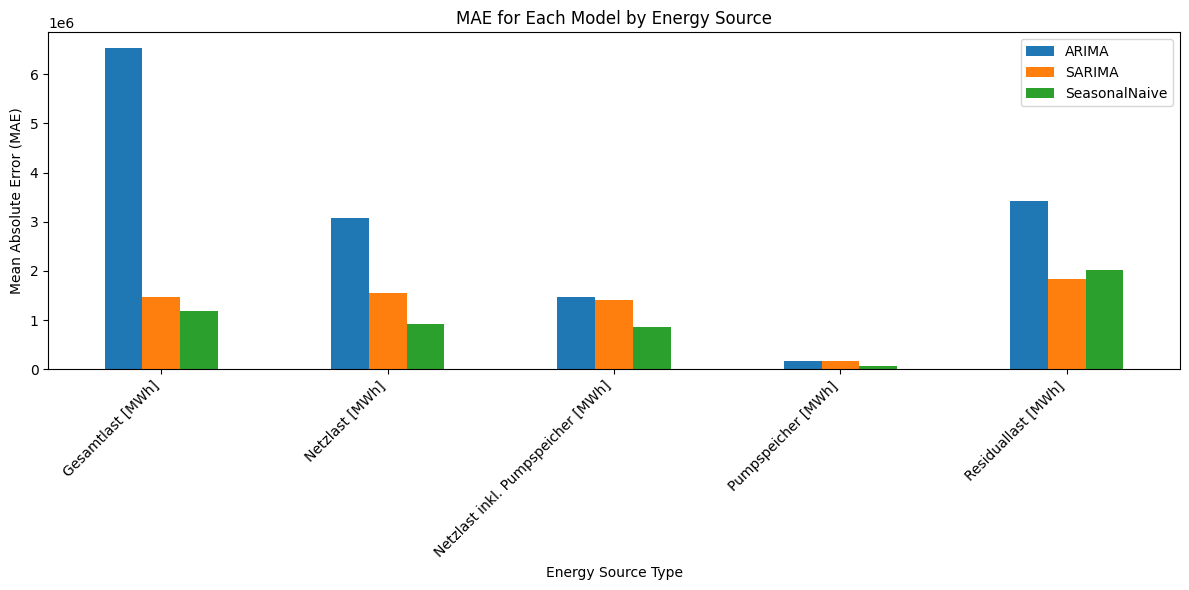

In [13]:
evaluation_for_plot = evaluation.set_index('unique_id')
evaluation_for_plot = evaluation_for_plot.drop(columns='metric')

evaluation_for_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Cross-Validation

In [14]:
models = [
    AutoARIMA(alias="ARIMA"),
    AutoARIMA(season_length=12, alias="SARIMA"),
    SeasonalNaive(season_length=12)
]

sf = StatsForecast(models=models, freq='MS')
cv = sf.cross_validation(
    df=trainVerbrauchStat,
    h=3,
    step_size=3,
    n_windows=4,
    refit=True,
)

cv.head()

,unique_id,ds,cutoff,y,ARIMA,SARIMA,SeasonalNaive
0,Gesamtlast [MWh],2024-09-01,2024-08-01,57537546.25,5.920632e+07,5.882437e+07,59455921.25
1,Gesamtlast [MWh],2024-10-01,2024-08-01,63916158.75,5.938707e+07,6.027289e+07,61117818.00
2,Gesamtlast [MWh],2024-11-01,2024-08-01,69646332.75,5.930549e+07,6.439126e+07,65115514.25
3,Gesamtlast [MWh],2024-12-01,2024-11-01,66598931.50,6.728951e+07,6.742638e+07,63032701.75
4,Gesamtlast [MWh],2025-01-01,2024-11-01,72011118.25,6.825887e+07,6.841292e+07,69057142.25


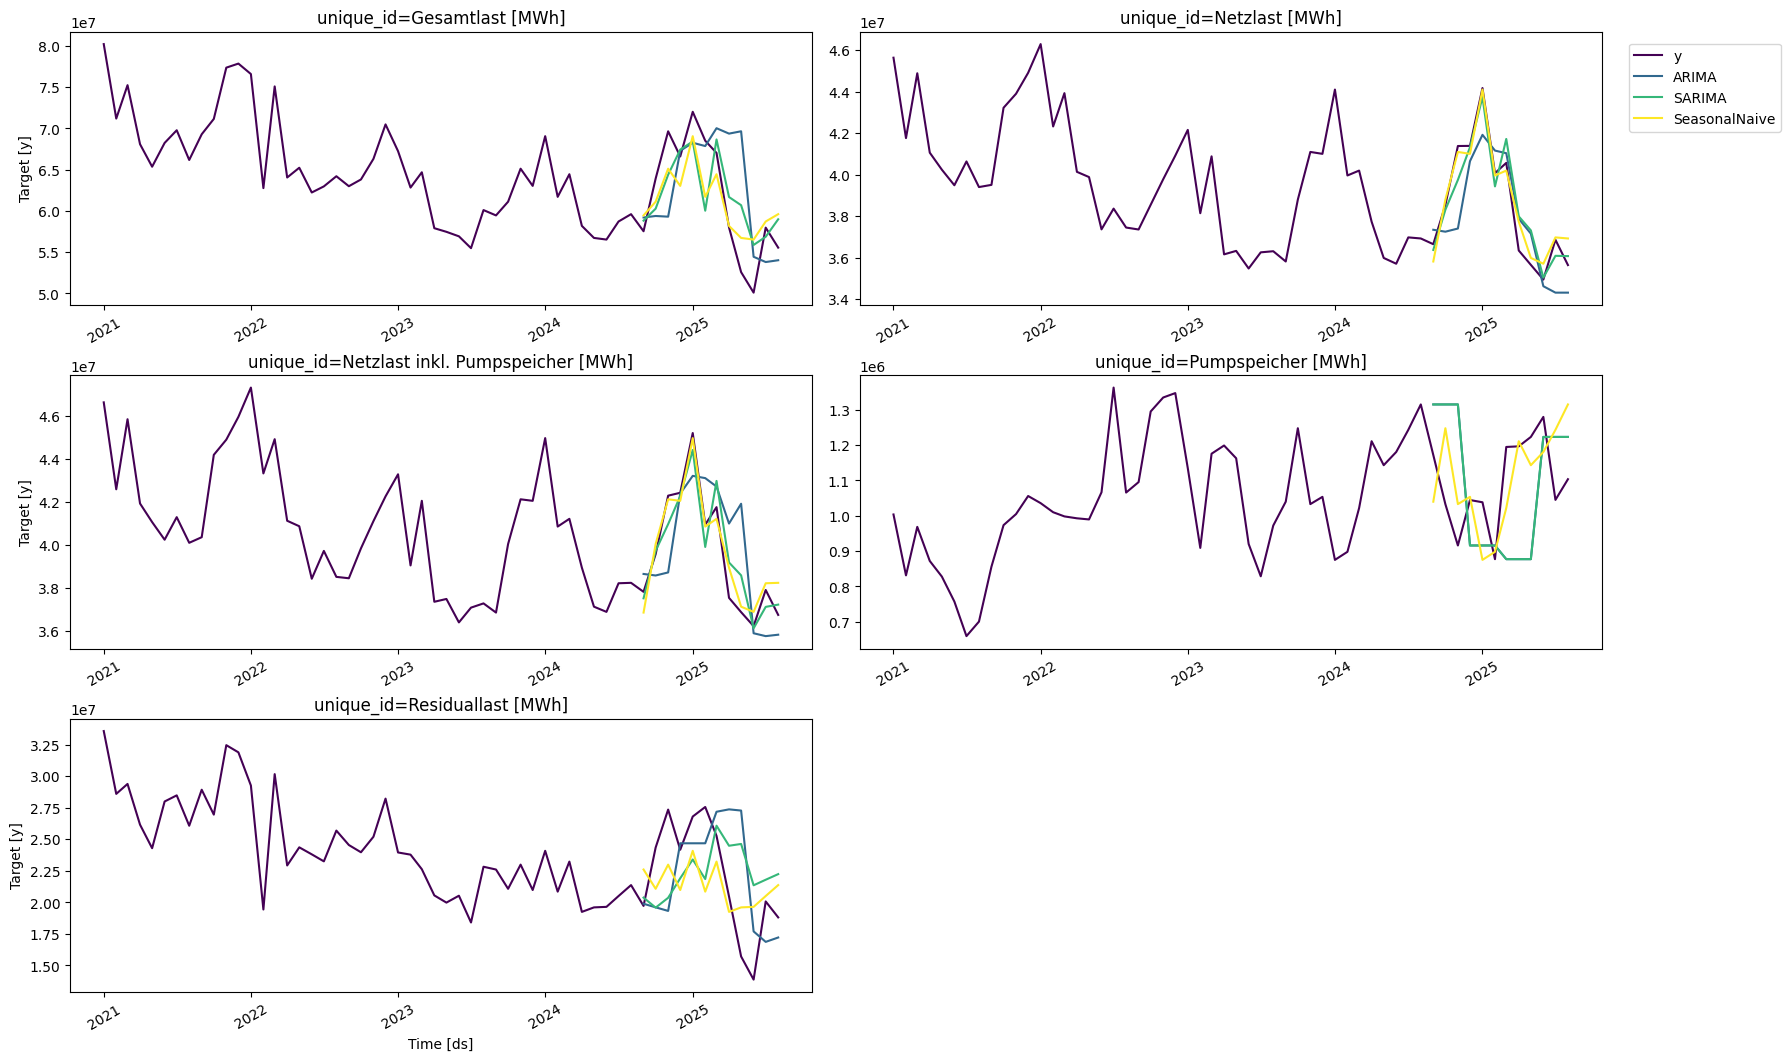

In [15]:
plot_series(df=trainVerbrauchStat, forecasts_df=cv.drop(columns=["y", "cutoff"]), palette="viridis")

In [16]:
cv_eval = evaluate(cv.drop(columns="cutoff"), metrics=[mae])

cv_eval = cv_eval.drop(columns=["unique_id"]).groupby("metric").mean().reset_index()
cv_eval

,metric,ARIMA,SARIMA,SeasonalNaive
0,mae,2.552806e+06,1.969689e+06,1.572574e+06


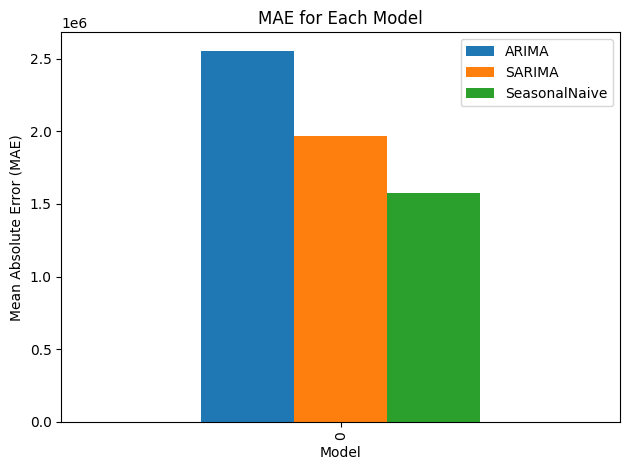

In [17]:
cv_eval.plot(kind="bar")
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Model")
plt.title("MAE for Each Model")
plt.tight_layout()
plt.show()

###MLForecast

In [18]:
testVerbrauch = verbrauch.tail(3)
trainVerbrauch = verbrauch.drop(testVerbrauch.index)

In [19]:
trainVerbrauch = trainVerbrauch.drop(columns="Datum bis").melt(id_vars=['Datum von'], var_name='unique_id', value_name='y')
testVerbrauch = testVerbrauch.drop(columns="Datum bis").melt(id_vars=['Datum von'], var_name='unique_id', value_name='y')

trainVerbrauch.rename(columns={'Datum von': 'ds'}, inplace=True)
testVerbrauch.rename(columns={'Datum von': 'ds'}, inplace=True)

display(trainVerbrauch.tail())
display(testVerbrauch.tail())

,ds,unique_id,y
275,2025-04-01,Residuallast [MWh],20466774.30
276,2025-05-01,Residuallast [MWh],15713463.76
277,2025-06-01,Residuallast [MWh],13879432.92
278,2025-07-01,Residuallast [MWh],20073336.05
279,2025-08-01,Residuallast [MWh],18809542.60


,ds,unique_id,y
10,2025-10-01,Pumpspeicher [MWh],1021747.39
11,2025-11-01,Pumpspeicher [MWh],908113.99
12,2025-09-01,Residuallast [MWh],18240659.33
13,2025-10-01,Residuallast [MWh],20225666.47
14,2025-11-01,Residuallast [MWh],26873492.46


In [20]:
models = [
    LinearRegression(),
    XGBRegressor(),
    LGBMRegressor()
]

mlf = MLForecast(models=models, freq='MS', lags=list(range(1, 12)), target_transforms=[LocalStandardScaler()])

mlf.fit(trainVerbrauch)
predMlVer = mlf.predict(3)

predMlVer.head()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000188 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 846
[LightGBM] [Info] Number of data points in the train set: 225, number of used features: 11
[LightGBM] [Info] Start training from score -0.117769
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,unique_id,ds,LinearRegression,XGBRegressor,LGBMRegressor
0,Gesamtlast [MWh],2025-09-01,6.116812e+07,6.060069e+07,5.864580e+07
1,Gesamtlast [MWh],2025-10-01,6.297794e+07,6.272996e+07,6.480232e+07
2,Gesamtlast [MWh],2025-11-01,6.791742e+07,6.413490e+07,6.462429e+07
3,Netzlast [MWh],2025-09-01,3.830262e+07,3.635496e+07,3.641584e+07
4,Netzlast [MWh],2025-10-01,3.915791e+07,3.875061e+07,3.985868e+07


In [21]:
eval_df = pd.merge(testVerbrauch, predMlVer, "left", ["ds", "unique_id"])
evaluation = evaluate(eval_df, metrics=[mae])
evaluation.head()

,unique_id,metric,LinearRegression,XGBRegressor,LGBMRegressor
0,Gesamtlast [MWh],mae,2.621303e+06,3.610340e+06,3.486367e+06
1,Netzlast [MWh],mae,1.209441e+06,1.125630e+06,5.433064e+05
2,Netzlast inkl. Pumpspeicher [MWh],mae,1.216545e+06,1.021900e+06,4.667507e+05
3,Pumpspeicher [MWh],mae,3.500805e+04,2.692218e+04,4.109568e+04
4,Residuallast [MWh],mae,2.432755e+06,3.010032e+06,2.321024e+06


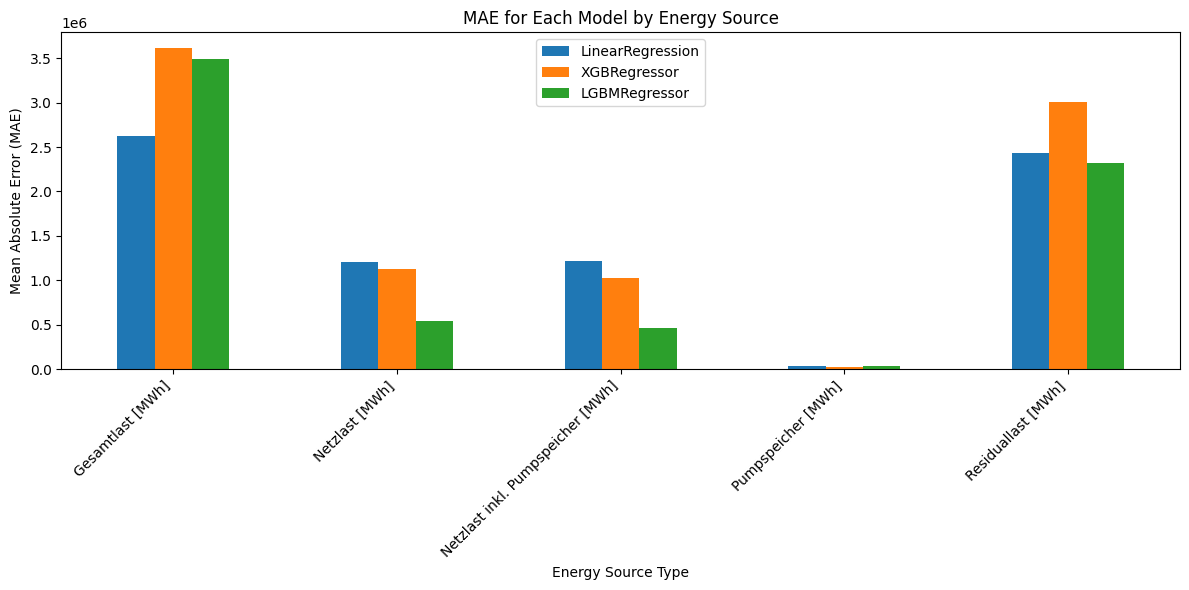

In [22]:
evaluation_to_plot = evaluation.drop(columns="metric").set_index("unique_id")

evaluation_to_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ML Cross-Validation

In [23]:
models = [
    LinearRegression(),
    XGBRegressor(),
    LGBMRegressor()
]

mlf = MLForecast(models=models, freq="MS", lags=list(range(1, 13)), target_transforms=[LocalStandardScaler()])

cv_ml = mlf.cross_validation(df=trainVerbrauch, n_windows=4, h=3)

cv_ml

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000053 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 660
[LightGBM] [Info] Number of data points in the train set: 160, number of used features: 12
[LightGBM] [Info] Start training from score -0.199793
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,unique_id,ds,cutoff,y,LinearRegression,XGBRegressor,LGBMRegressor
0,Gesamtlast [MWh],2024-09-01,2024-08-01,57537546.25,6.121763e+07,5.762899e+07,5.868810e+07
1,Gesamtlast [MWh],2024-10-01,2024-08-01,63916158.75,6.172796e+07,6.019498e+07,6.003844e+07
2,Gesamtlast [MWh],2024-11-01,2024-08-01,69646332.75,6.399196e+07,6.339737e+07,6.276590e+07
3,Netzlast [MWh],2024-09-01,2024-08-01,36646160.50,3.775755e+07,3.703432e+07,3.650115e+07
4,Netzlast [MWh],2024-10-01,2024-08-01,38537384.00,3.847505e+07,3.763587e+07,3.863660e+07
5,Netzlast [MWh],2024-11-01,2024-08-01,41376520.00,3.950627e+07,3.867355e+07,3.952337e+07
6,Netzlast inkl. Pumpspeicher [MWh],2024-09-01,2024-08-01,37817959.50,3.896061e+07,3.802862e+07,3.850725e+07
7,Netzlast inkl. Pumpspeicher [MWh],2024-10-01,2024-08-01,39570038.25,3.965347e+07,3.865667e+07,4.016215e+07
8,Netzlast inkl. Pumpspeicher [MWh],2024-11-01,2024-08-01,42292498.75,4.052657e+07,3.970029e+07,4.098758e+07
9,Pumpspeicher [MWh],2024-09-01,2024-08-01,1171799.00,1.173797e+06,1.121258e+06,1.141187e+06


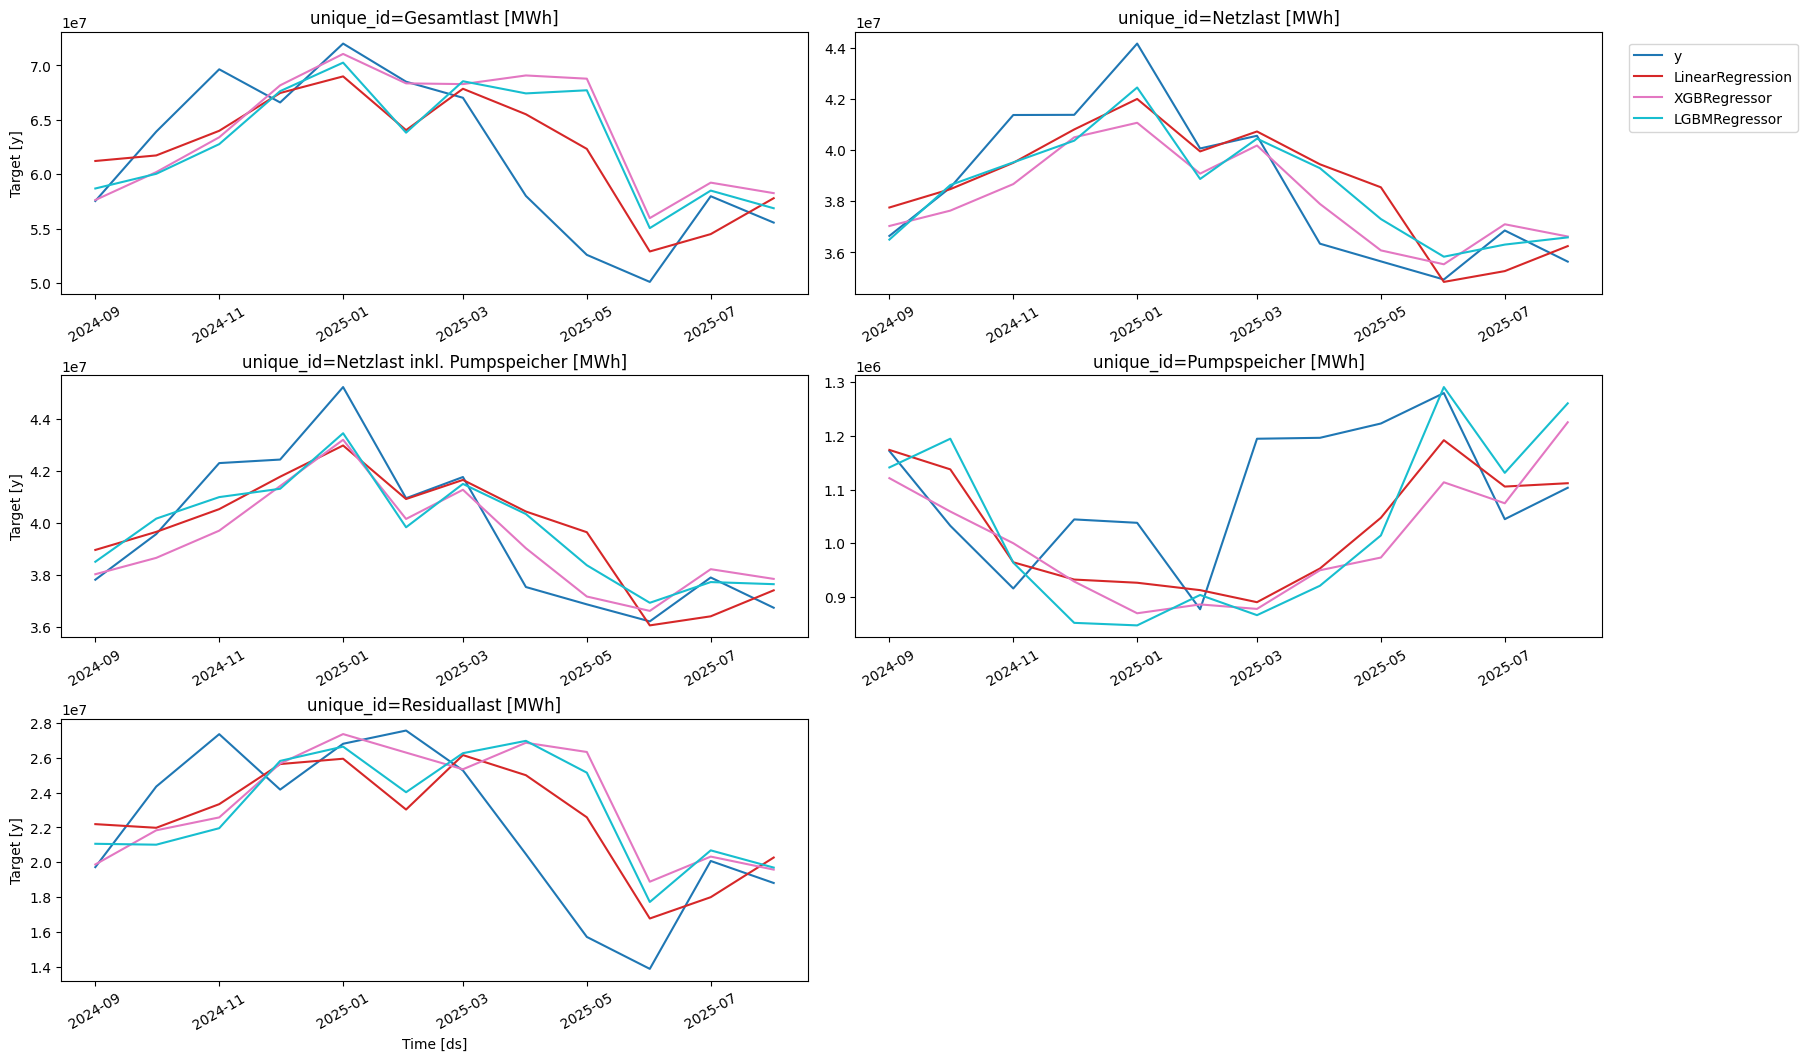

In [24]:
plot_series(forecasts_df=cv_ml.drop(columns='cutoff'))

In [25]:
mlf_cv_eval = evaluate(cv_ml.drop(columns="cutoff"), metrics=[mae])

mlf_cv_eval = mlf_cv_eval.drop(columns=["unique_id"]).groupby("metric").mean().reset_index()
mlf_cv_eval

,metric,LinearRegression,XGBRegressor,LGBMRegressor
0,mae,1.842465e+06,1.855581e+06,1.962202e+06


<Axes: >

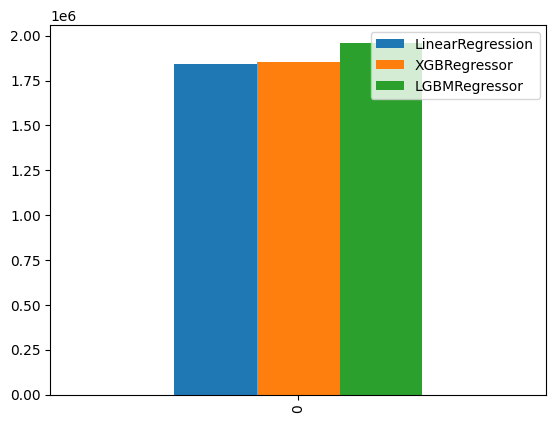

In [26]:
mlf_cv_eval.plot(kind="bar")

In [27]:
mlf_cv_eval = evaluate(cv_ml.drop(columns="cutoff"), metrics=[mae])
mlf_to_plot = mlf_cv_eval.drop(columns="metric").set_index("unique_id")
mlf_to_plot

,LinearRegression,XGBRegressor,LGBMRegressor
unique_id,,,
Gesamtlast [MWh],3.871625e+06,4.257620e+06,4.353784e+06
Netzlast [MWh],1.196765e+06,1.095073e+06,1.094662e+06
Netzlast inkl. Pumpspeicher [MWh],1.167287e+06,9.711594e+05,1.079171e+06
Pumpspeicher [MWh],1.078641e+05,1.320169e+05,1.430759e+05
Residuallast [MWh],2.868783e+06,2.822035e+06,3.140319e+06


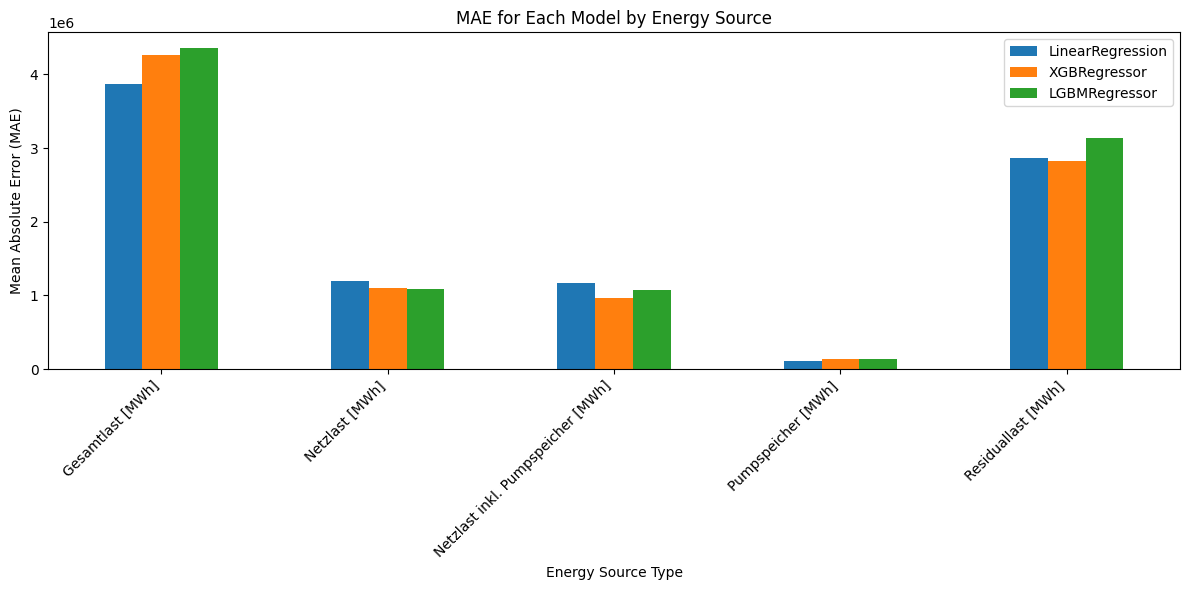

In [28]:
mlf_to_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###NeuralForecast

In [29]:
models = [
    NHITS(h=3, input_size=12, n_pool_kernel_size=[4,2,1], n_freq_downsample=[12,4,1], scaler_type='robust', max_steps=1000, enable_progress_bar=False),
    TFT(h=3, input_size=12, hidden_size=128, scaler_type='robust', learning_rate=5e-4, max_steps=500, enable_progress_bar=False)
]

nf = NeuralForecast(models=models, freq='MS', local_scaler_type="standard")

nf.fit(trainVerbrauch)
predNNVer = nf.predict(h=3)

predNNVer.head()

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.4 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.4 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                    ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                    │ MAE                      │      0 │ train │     0 │
│ 1 │ padder_train            │ ConstantPad1d            │      0 │ train │     0 │
│ 2 │ scaler                  │ TemporalNorm             │      0 │ train │     0 │
│ 3 │ embedding               │ TFTEmbedding             │    512 │ train │     0 │
│ 4 │ temporal_encoder        │ TemporalCovariateEncoder │  613 K │ train │     0 │
│ 5 │ temporal_fusion_decoder │ TemporalFusionDecoder    │  256 K │ train │     0 │
│ 6 │ output_adapter          │ Linear                   │    129 │ train │     0 │
└───┴─────────────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 870 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 870 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 88                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


,unique_id,ds,NHITS,TFT
0,Gesamtlast [MWh],2025-09-01,52539256.0,61846272.0
1,Gesamtlast [MWh],2025-10-01,64430256.0,70945248.0
2,Gesamtlast [MWh],2025-11-01,68988384.0,76020216.0
3,Netzlast [MWh],2025-09-01,35442456.0,36975592.0
4,Netzlast [MWh],2025-10-01,38246984.0,39311908.0


In [30]:
eval_df = pd.merge(testVerbrauch, predNNVer, how="left", on=["ds", "unique_id"])
evaluation = evaluate(eval_df, metrics=[mae])
evaluation.head()

,unique_id,metric,NHITS,TFT
0,Gesamtlast [MWh],mae,2.209250e+06,7.078339e+06
1,Netzlast [MWh],mae,1.500484e+06,5.544404e+05
2,Netzlast inkl. Pumpspeicher [MWh],mae,1.488090e+06,5.729214e+05
3,Pumpspeicher [MWh],mae,7.547186e+04,9.275593e+04
4,Residuallast [MWh],mae,2.591196e+06,6.233826e+06


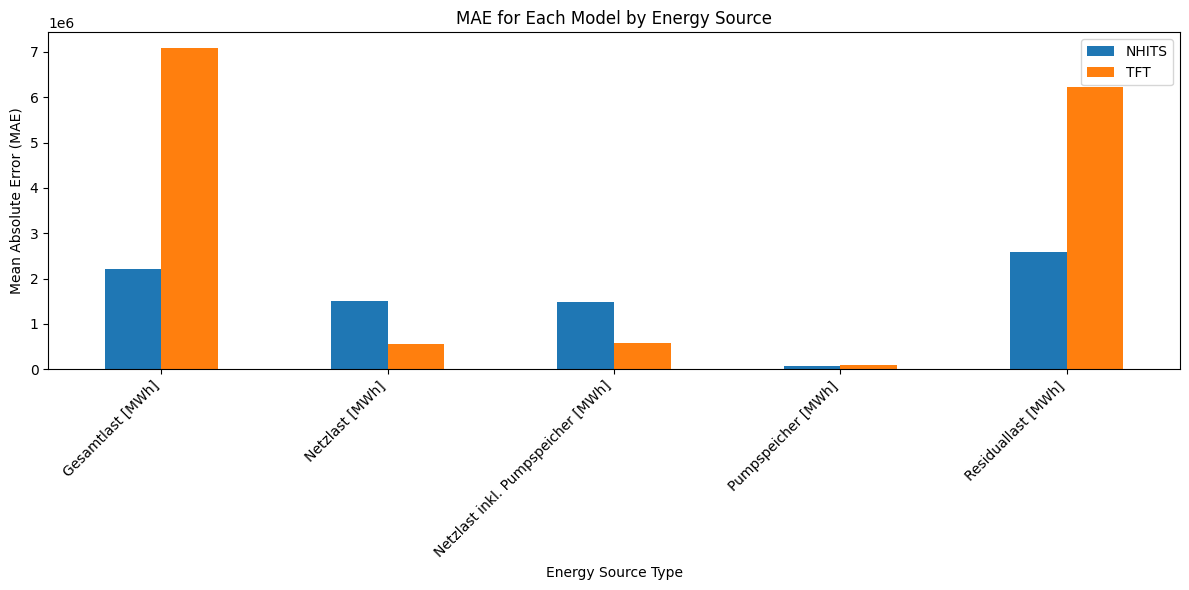

In [31]:
evaluation_to_plot = evaluation.drop(columns="metric").set_index("unique_id")

evaluation_to_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

NN Cross-Validation

In [32]:
models = [
    NHITS(h=3, input_size=12, n_pool_kernel_size=[4,2,1], n_freq_downsample=[12,4,1], scaler_type='robust', max_steps=1000, enable_progress_bar=False),
    TFT(h=3, input_size=12, hidden_size=128, scaler_type='robust', learning_rate=5e-4, max_steps=500, enable_progress_bar=False)
]

nf = NeuralForecast(models=models, freq='MS', local_scaler_type="standard")

cv_nf = nf.cross_validation(trainVerbrauch, n_windows=4, step_size=3)
cv_nf.head()

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.4 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.4 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                    ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                    │ MAE                      │      0 │ train │     0 │
│ 1 │ padder_train            │ ConstantPad1d            │      0 │ train │     0 │
│ 2 │ scaler                  │ TemporalNorm             │      0 │ train │     0 │
│ 3 │ embedding               │ TFTEmbedding             │    512 │ train │     0 │
│ 4 │ temporal_encoder        │ TemporalCovariateEncoder │  613 K │ train │     0 │
│ 5 │ temporal_fusion_decoder │ TemporalFusionDecoder    │  256 K │ train │     0 │
│ 6 │ output_adapter          │ Linear                   │    129 │ train │     0 │
└───┴─────────────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 870 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 870 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 88                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


,unique_id,ds,cutoff,NHITS,TFT,y
0,Gesamtlast [MWh],2024-09-01,2024-08-01,58878364.0,57691192.0,57537546.25
1,Gesamtlast [MWh],2024-10-01,2024-08-01,62018920.0,57981172.0,63916158.75
2,Gesamtlast [MWh],2024-11-01,2024-08-01,66918060.0,58958596.0,69646332.75
3,Gesamtlast [MWh],2024-12-01,2024-11-01,67424112.0,67664536.0,66598931.50
4,Gesamtlast [MWh],2025-01-01,2024-11-01,71453632.0,64115672.0,72011118.25


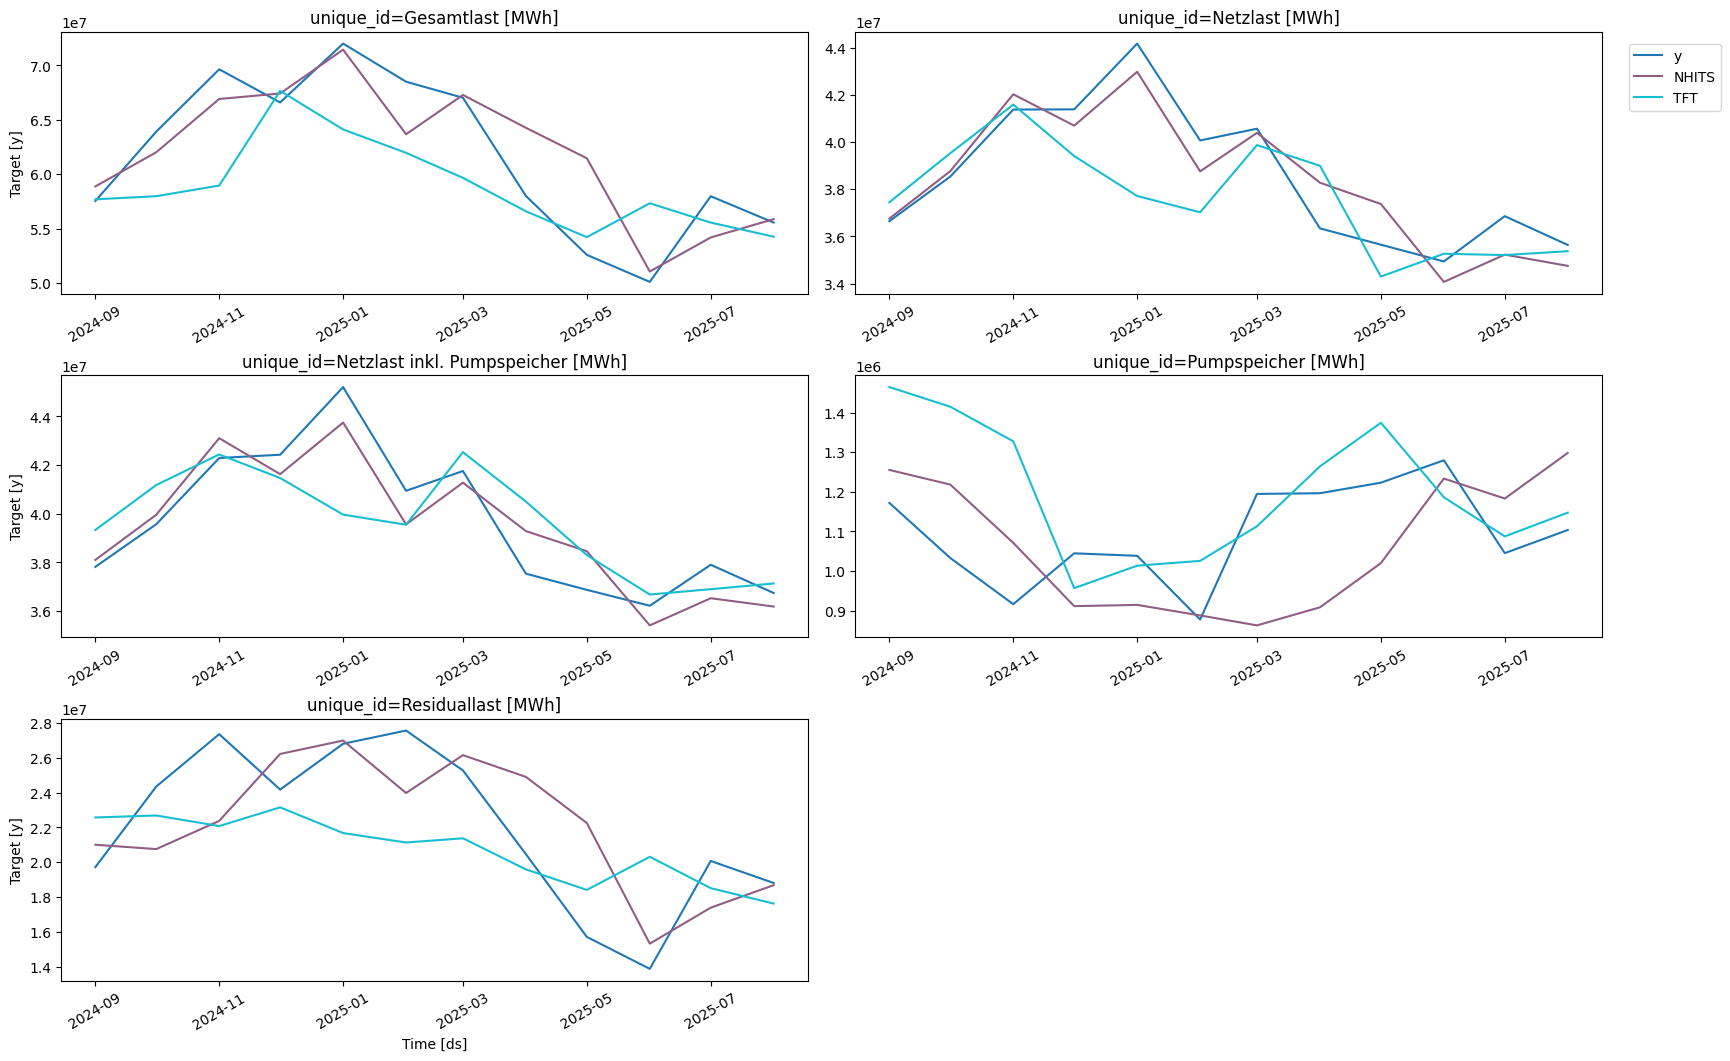

In [33]:
plot_series(forecasts_df=cv_nf.drop(columns='cutoff'))

<Axes: >

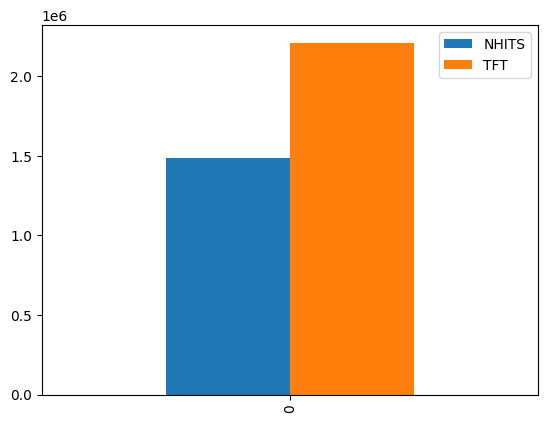

In [34]:
nf_cv_eval = evaluate(cv_nf.drop(columns="cutoff"), metrics=[mae])

nf_cv_eval = nf_cv_eval.drop(columns=["unique_id"]).groupby("metric").mean().reset_index()
nf_cv_eval.plot(kind="bar")

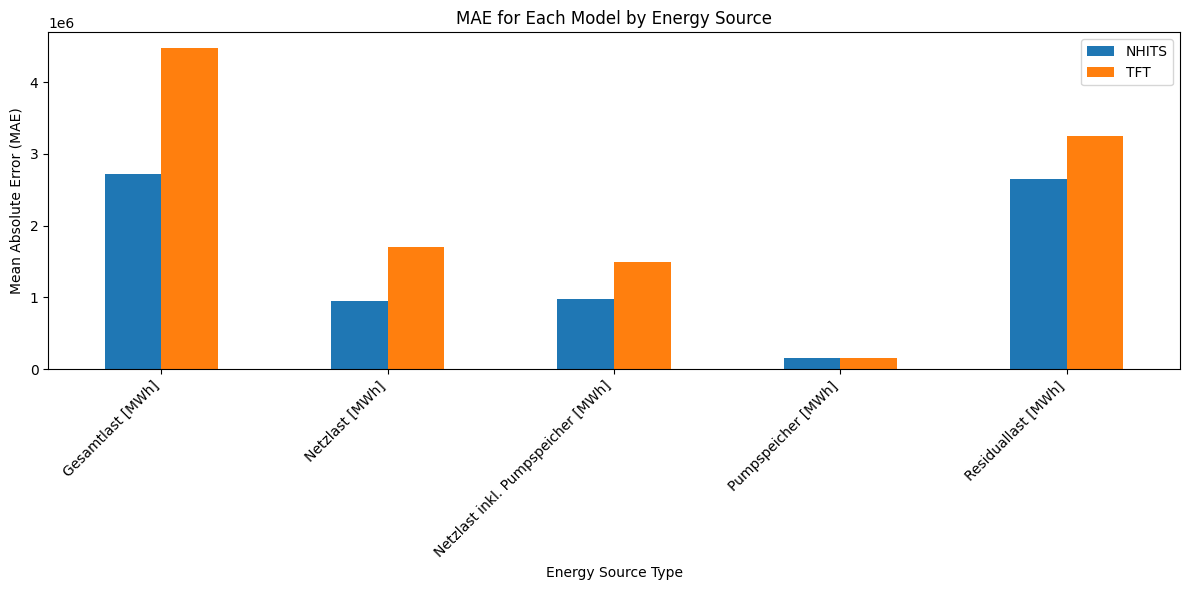

In [35]:
nf_cv_eval = evaluate(cv_nf.drop(columns="cutoff"), metrics=[mae])
nf_to_plot = nf_cv_eval.drop(columns="metric").set_index("unique_id")

nf_to_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Combined Plots

MAE

In [36]:
nf_cv_eval_tc = nf_cv_eval.drop(columns="metric")
mlf_cv_eval_tc = mlf_cv_eval.drop(columns="metric")
cv_eval_tc = evaluate(cv.drop(columns="cutoff"), metrics=[mae]).drop(columns="metric")

In [37]:
combined_cv = pd.merge(cv_eval_tc, mlf_cv_eval_tc)
combined_cv = pd.merge(combined_cv, nf_cv_eval_tc)
combined_cv = combined_cv.set_index("unique_id")
combined_cv

,ARIMA,SARIMA,SeasonalNaive,LinearRegression,XGBRegressor,LGBMRegressor,NHITS,TFT
unique_id,,,,,,,,
Gesamtlast [MWh],5.257015e+06,3.902097e+06,3.391860e+06,3.871625e+06,4.257620e+06,4.353784e+06,2.720005e+06,4.468554e+06
Netzlast [MWh],1.477982e+06,7.533104e+05,5.166951e+05,1.196765e+06,1.095073e+06,1.094662e+06,9.496805e+05,1.701385e+06
Netzlast inkl. Pumpspeicher [MWh],1.870891e+06,8.089846e+05,5.817394e+05,1.167287e+06,9.711594e+05,1.079171e+06,9.736844e+05,1.491284e+06
Pumpspeicher [MWh],2.041506e+05,2.041506e+05,1.193690e+05,1.078641e+05,1.320169e+05,1.430759e+05,1.578582e+05,1.523148e+05
Residuallast [MWh],3.953990e+06,4.179902e+06,3.253206e+06,2.868783e+06,2.822035e+06,3.140319e+06,2.648026e+06,3.250566e+06


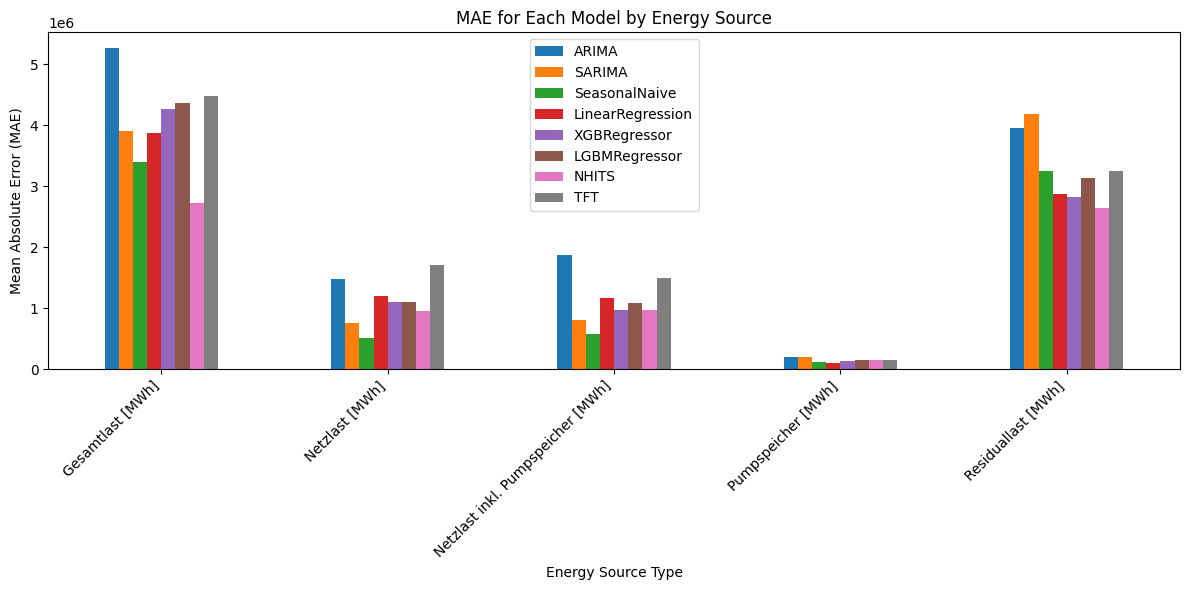

In [38]:
combined_cv.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Combined Predictions

In [45]:
combinedPreds = pd.merge(testVerbrauch, predStatVer, "left", ["ds", "unique_id"])
combinedPreds = pd.merge(combinedPreds, predMlVer, "left", ["ds", "unique_id"])
combinedPreds = pd.merge(combinedPreds, predNNVer, "left", ["ds", "unique_id"])
combinedPreds.head()

,ds,unique_id,y,ARIMA,SARIMA,SeasonalNaive,LinearRegression,XGBRegressor,LGBMRegressor,NHITS,TFT
0,2025-09-01,Gesamtlast [MWh],56044932.24,5.636930e+07,5.543007e+07,57537546.25,6.116812e+07,6.060069e+07,5.864580e+07,52539256.0,61846272.0
1,2025-10-01,Gesamtlast [MWh],61925792.95,5.609440e+07,6.066466e+07,63916158.75,6.297794e+07,6.272996e+07,6.480232e+07,64430256.0,70945248.0
2,2025-11-01,Gesamtlast [MWh],69605993.86,5.618698e+07,6.706728e+07,69646332.75,6.791742e+07,6.413490e+07,6.462429e+07,68988384.0,76020216.0
3,2025-09-01,Netzlast [MWh],36808238.41,3.739869e+07,3.593658e+07,36646160.50,3.830262e+07,3.635496e+07,3.641584e+07,35442456.0,36975592.0
4,2025-10-01,Netzlast [MWh],40678379.09,3.693534e+07,3.797908e+07,38537384.00,3.915791e+07,3.875061e+07,3.985868e+07,38246984.0,39311908.0


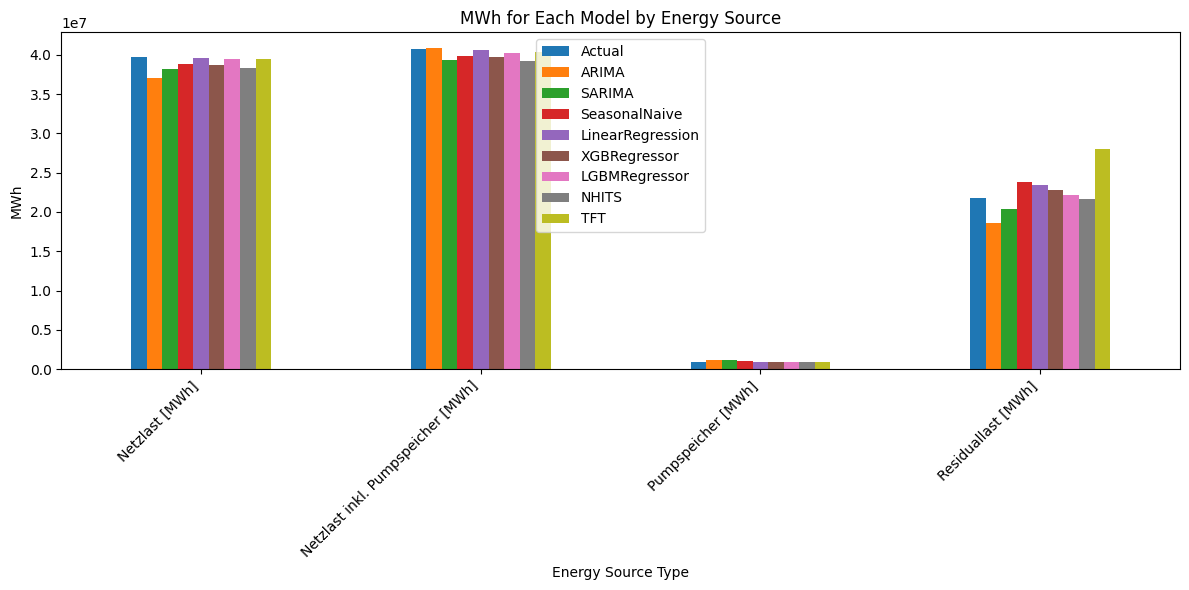

In [40]:
combPredsExGesamt = combinedPreds.loc[combinedPreds["unique_id"] != "Gesamtlast [MWh]"]
combPredsExGesamt = combPredsExGesamt.drop(columns="ds")
combPredsExGesamt = combPredsExGesamt.set_index("unique_id")
combPredsExGesamt = combPredsExGesamt.rename(columns={"y": "Actual"})

combPredsExGesamt.groupby(combPredsExGesamt.index).mean().plot(kind="bar", figsize=(12, 6))
plt.ylabel("MWh")
plt.xlabel("Energy Source Type")
plt.title("MWh for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

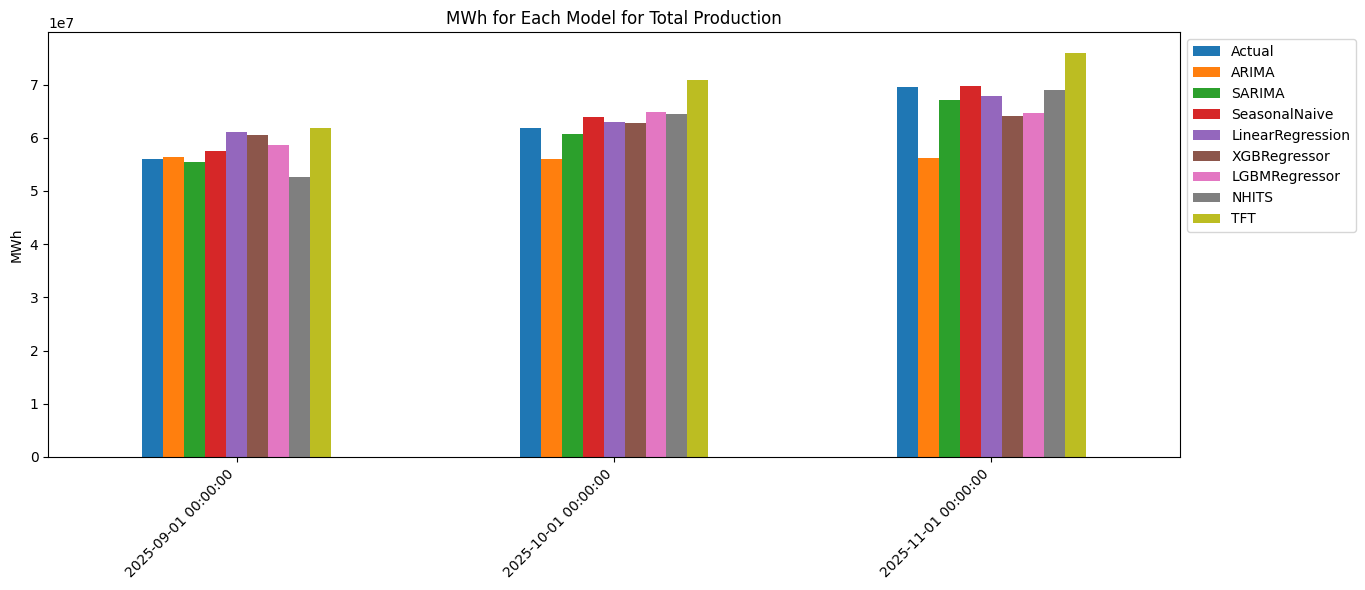

In [41]:
combPredsGesamt = combinedPreds.loc[combinedPreds["unique_id"] == "Gesamtlast [MWh]"]
combPredsGesamt = combPredsGesamt.drop(columns="unique_id")
combPredsGesamt = combPredsGesamt.set_index("ds")
combPredsGesamt = combPredsGesamt.rename(columns={"y": "Actual"})

combPredsGesamt.groupby(combPredsGesamt.index).mean().plot(kind="bar", figsize=(12, 6))
plt.ylabel("MWh")
plt.xlabel("")
plt.title("MWh for Each Model for Total Production")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

###Forecast Plot with Best ML Model

In [42]:
statmodels = ["ARIMA", "SARIMA", "SeasonalNaive"]
bestForecastModel = combined_cv.loc["Gesamtlast [MWh]"].drop(labels=statmodels, axis=0).idxmin()
bestForecastModel

'NHITS'

In [43]:
forecast = combinedPreds.loc[combinedPreds["unique_id"] == "Gesamtlast [MWh]", ["ds", bestForecastModel]]
forecast = forecast.set_index("ds")
forecast

,NHITS
ds,
2025-09-01,52539256.0
2025-10-01,64430256.0
2025-11-01,68988384.0


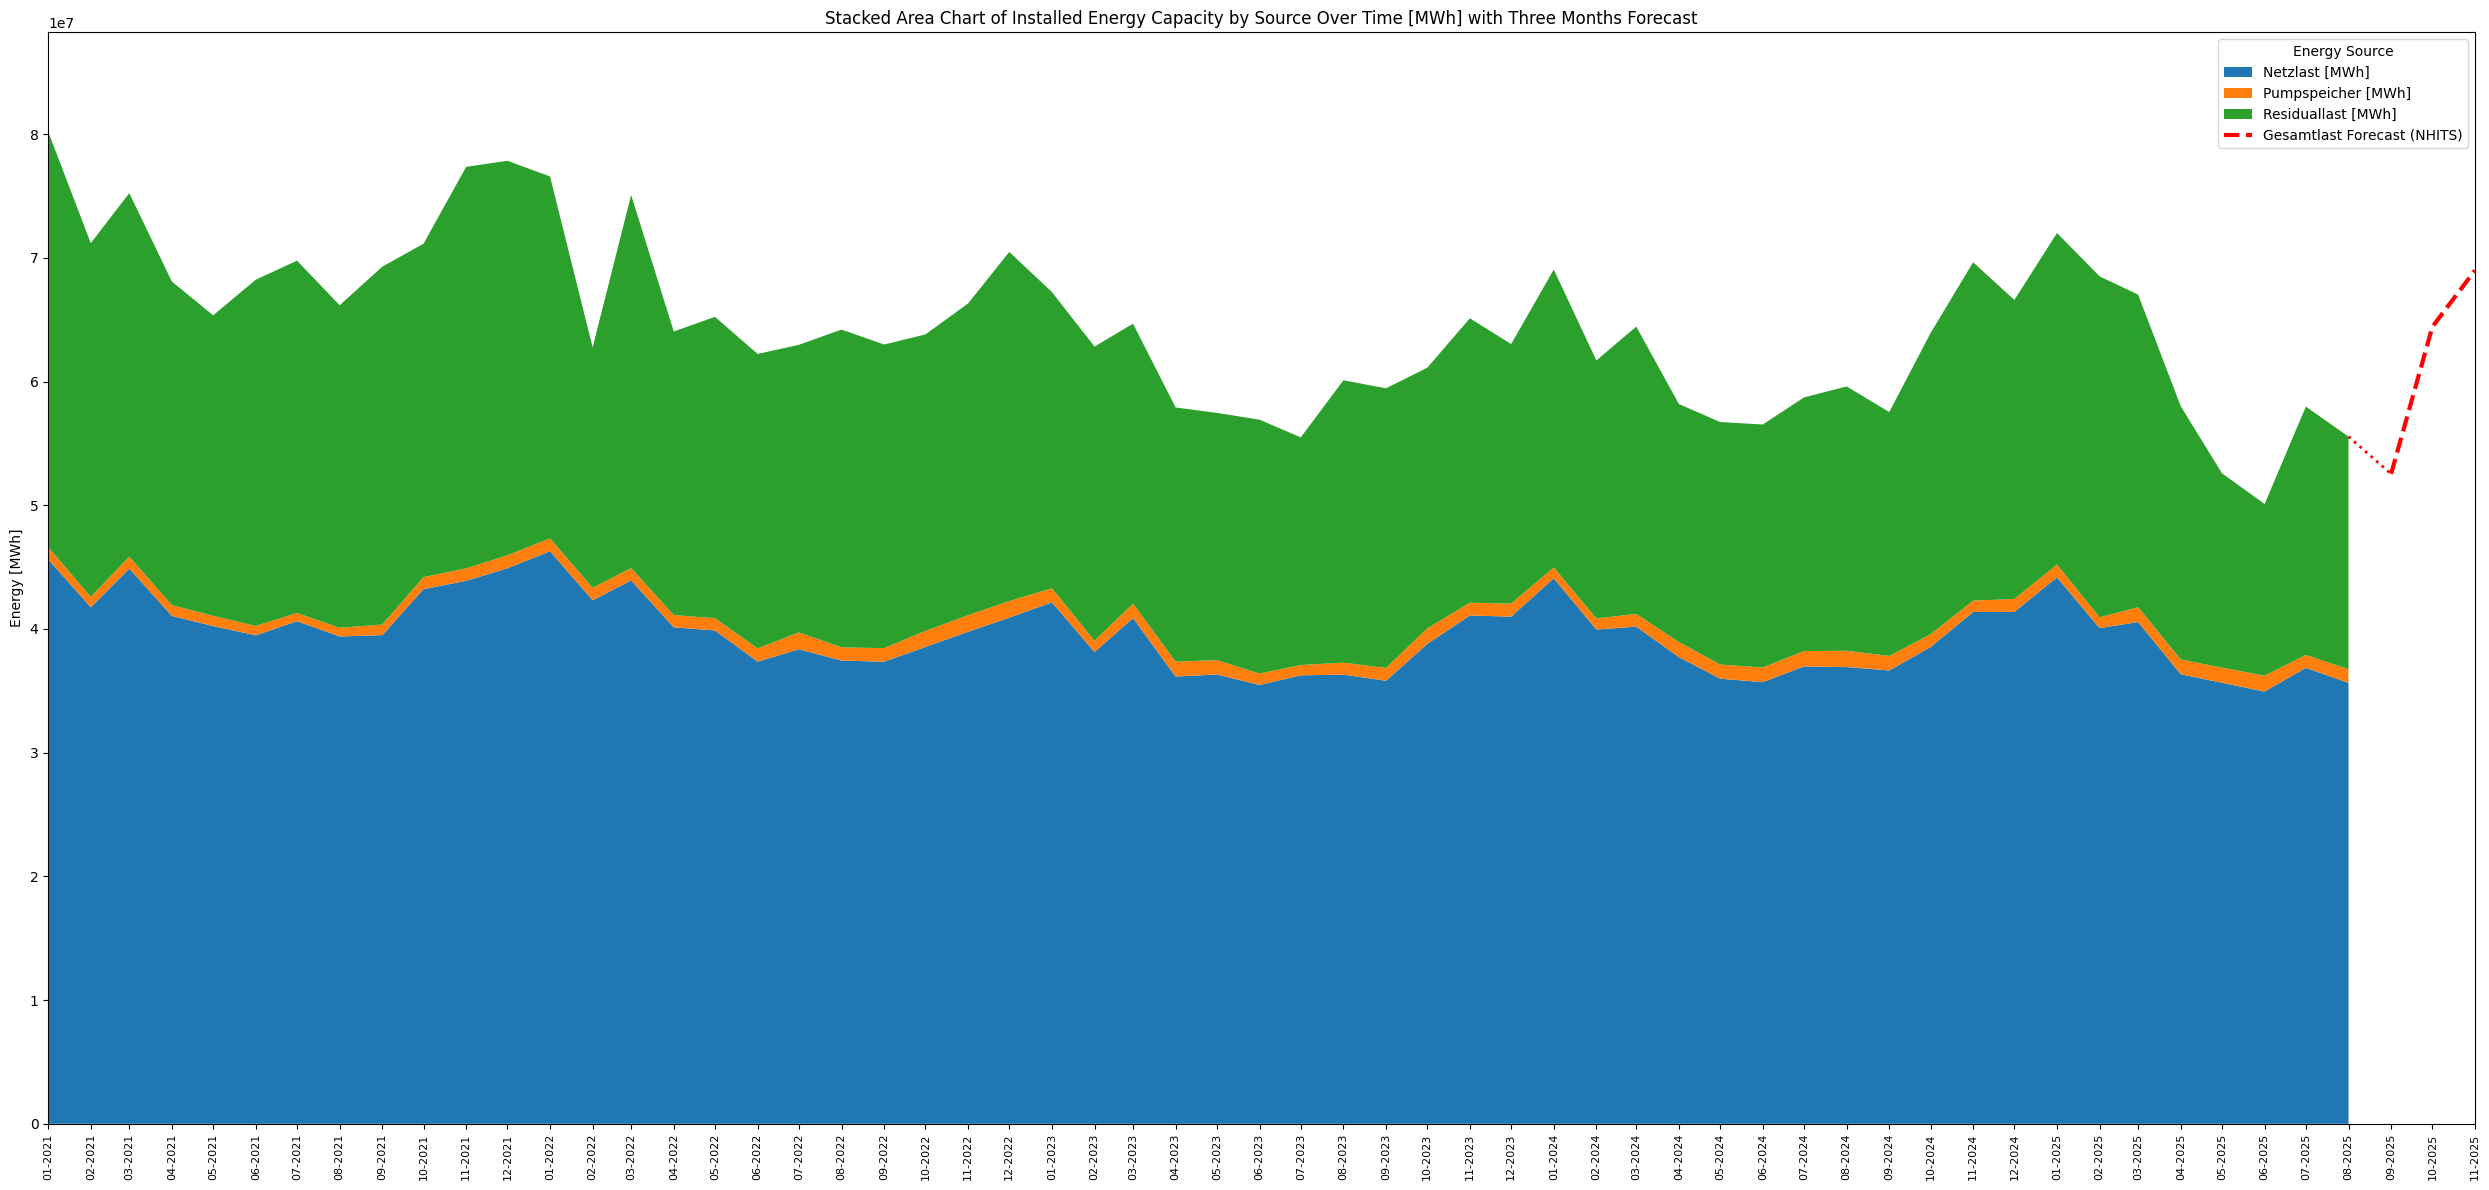

In [46]:
verbrauchPlotDf = verbrauch.iloc[:-3].set_index("Datum von").drop(columns=["Datum bis", "Gesamtlast [MWh]", "Netzlast inkl. Pumpspeicher [MWh]"])

productionDates = verbrauchPlotDf.index
forecastDates = forecast.index
allDates = productionDates.append(forecastDates)
allLabels = allDates.strftime("%m-%Y")

fig, ax = plt.subplots(figsize=(25, 12))

ax.stackplot(verbrauchPlotDf.index, verbrauchPlotDf.values.T, labels=verbrauchPlotDf.columns)
ax.plot(forecast.index, forecast[bestForecastModel], color='red', linestyle="--", linewidth=3, label=f'Gesamtlast Forecast ({bestForecastModel})')

last_historical_total = verbrauchPlotDf.sum(axis=1).iloc[-1]
first_forecast_value = forecast[bestForecastModel].iloc[0]

bridge_x = [productionDates.max(), forecastDates.min()]
bridge_y = [last_historical_total, first_forecast_value]
ax.plot(bridge_x, bridge_y, color='red', linestyle=':', linewidth=2)

max_historical_sum = verbrauchPlotDf.sum(axis=1).max()
max_forecast_value = forecast[f'{bestForecastModel}'].max()
max_y_value = max(max_historical_sum, max_forecast_value)
ax.set_ylim(bottom=0, top=max_y_value * 1.1)

ax.set_xlim(allDates.min(), allDates.max())
ax.set_xticks(allDates)
ax.set_xticklabels(allLabels, rotation=90, ha='center', fontsize=8)

ax.set_title('Stacked Area Chart of Installed Energy Capacity by Source Over Time [MWh] with Three Months Forecast')
ax.set_ylabel('Energy [MWh]')
ax.set_xlabel('')
ax.legend(title='Energy Source', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()